# Assignment 11: Fine-Tuning GPT-2 on a Custom Text Style

**Objective:** To understand how fine-tuning changes the writing style of a pretrained GPT-2 model by training it on a small, original dialogue dataset.

This experiment uses an original **mystery/detective conversation style** rather than a published literary text. The dataset contains short investigation-themed lines with a tense, questioning tone.


## Step 1: Installing and Importing Libraries

The required Hugging Face Transformers and PyTorch libraries are installed first.

In [1]:
!pip install -q transformers torch accelerate


In [2]:
import torch
import transformers
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("transformers version:", transformers.__version__)
print("Using device:", device)


transformers version: 5.18.0
Using device: cuda


## Step 2: Loading the Original GPT-2 and a Copy for Fine-Tuning

Two separate copies of the small GPT-2 model are loaded. The first remains unchanged and acts as the **base model**. The second starts with the same weights and is fine-tuned on the custom dialogue dataset. Using two copies makes the before-and-after comparison fair.


In [3]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

base_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
finetuned_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

tokenizer.pad_token = tokenizer.eos_token

total_parameters = sum(p.numel() for p in base_model.parameters())
same_weights = torch.equal(
    base_model.transformer.wte.weight,
    finetuned_model.transformer.wte.weight
)

print("Padding token:", tokenizer.pad_token)
print("Number of parameters:", total_parameters)
print("Both models start with the same weights:", same_weights)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Padding token: <|endoftext|>
Number of parameters: 124439808
Both models start with the same weights: True


## Step 3: Generating Text from the Original GPT-2 (Before Fine-Tuning)

Two original prompts are used for the experiment. They are deliberately different from the sample notebook. The same prompts, generation settings and random seeds will later be given to the fine-tuned model, so the comparison focuses on the effect of fine-tuning.


In [4]:
prompts = {
    "Investigation prompt": "The detective placed the photograph on the table and said,",
    "Story prompt": "At midnight, the train stopped in the middle of the forest, and"
}

seeds = [1, 2, 3]

def generate_text(model, prompt, seed):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    torch.manual_seed(seed)

    output = model.generate(
        **inputs,
        max_new_tokens=60,
        do_sample=True,
        temperature=0.7,
        top_k=50,
        top_p=0.95,
        repetition_penalty=1.2,
        pad_token_id=tokenizer.eos_token_id
    )

    return tokenizer.decode(output[0], skip_special_tokens=True)

base_outputs = {}

for name, prompt in prompts.items():
    print("=" * 70)
    print(name, ":", prompt)

    for seed in seeds:
        text = generate_text(base_model, prompt, seed)
        base_outputs[(name, seed)] = text
        print(f"\n--- Base model, sample {seed} ---")
        print(text)


Investigation prompt : The detective placed the photograph on the table and said,

--- Base model, sample 1 ---
The detective placed the photograph on the table and said, "We have to take it."
 [A police officer with a copy of his arrest file was shown in this photo.] The video shows two officers holding up handcuffs. One grabs one foot from another as he says that you can't walk down stairs without being arrested; then pulls out an automatic weapon

--- Base model, sample 2 ---
The detective placed the photograph on the table and said, "Well you know that's a pretty good picture."
"But I think there was nothing to it. The other day we went out with an ambulance driver who'd been driving for about 20 minutes so they could see us," he says of his experience at police stations in New York City after being

--- Base model, sample 3 ---
The detective placed the photograph on the table and said, "Well you know what they call it. It's not a gun."
"Oh," he replied with an exasperated laugh as

## Step 4: Collecting the Custom Dataset

Instead of using Shakespeare or another published text, this experiment uses **240 original dialogue-style lines** written specifically for this assignment. The lines describe a fictional detective investigation involving clues, witnesses, keys, photographs and unexplained events.

The dataset is intentionally small and has a consistent tone: short spoken statements, questions, suspicion and investigation-focused vocabulary. The original dataset is saved as `original_dataset.txt` so it can be submitted with the notebook.


In [5]:
# Original 240-line dataset created for this experiment
original_lines = ['The rain had stopped, but the street still reflected every blue light.', 'The safest assumption is that the first story is incomplete.', 'That difference matters.', 'The detective studied the key without touching it.', 'Ask the same question tomorrow and see who changes the answer.', 'Every clue becomes useful when we put it beside another clue.', 'The map on the wall had one street circled in red.', 'Keep the door open; I want to hear anyone approaching.', 'Someone erased the name, but they forgot the date.', 'The note contained only six words, but they changed the case.', 'Then the key is not for the door we thought it was for.', 'The clock is wrong, and that may be the most honest thing here.', '[door closes]', 'Maybe the person who left it wanted us to follow.', 'Do not call the police yet.', 'The old radio crackled once and then became silent.', 'Do you remember what happened before the lights went out?', 'We need one more fact before we make the accusation.', 'The elevator opened on a floor that should have been empty.', 'I remember the sound, but not the footsteps.', 'Then someone wanted us to notice the wrong detail.', 'The clock above the station had stopped at eleven seventeen.', 'That difference matters.', 'Do not touch it yet; fingerprints may tell us more than the lock.', 'The witness looked toward the window before answering.', 'Every clue becomes useful when we put it beside another clue.', 'Who knew you would come back tonight?', 'The missing photograph was not where I had left it.', 'Someone erased the name, but they forgot the date.', 'Everyone in this building has a reason to lie.', 'The rain had stopped, but the street still reflected every blue light.', 'The clock is wrong, and that may be the most honest thing here.', 'That is why I wrote down the time before I asked the question.', 'The detective studied the key without touching it.', 'Do not call the police yet.', 'Look at the corner, not the center; people hide clues where nobody looks.', 'The map on the wall had one street circled in red.', 'We need one more fact before we make the accusation.', 'We should not trust a message simply because it sounds urgent.', 'The note contained only six words, but they changed the case.', 'Then someone wanted us to notice the wrong detail.', 'The safest assumption is that the first story is incomplete.', 'The envelope was waiting on the desk when I returned.', 'Do not touch it yet; fingerprints may tell us more than the lock.', 'Ask the same question tomorrow and see who changes the answer.', 'The old radio crackled once and then became silent.', 'Who knew you would come back tonight?', 'Keep the door open; I want to hear anyone approaching.', 'The elevator opened on a floor that should have been empty.', 'Everyone in this building has a reason to lie.', 'Then the key is not for the door we thought it was for.', 'The clock above the station had stopped at eleven seventeen.', 'That is why I wrote down the time before I asked the question.', 'Maybe the person who left it wanted us to follow.', 'The witness looked toward the window before answering.', '   ', 'Do you remember what happened before the lights went out?', 'The missing photograph was not where I had left it.', 'We should not trust a message simply because it sounds urgent.', 'I remember the sound, but not the footsteps.', 'The rain had stopped, but the street still reflected every blue light.', 'The safest assumption is that the first story is incomplete.', 'That difference matters.', 'The detective studied the key without touching it.', 'Ask the same question tomorrow and see who changes the answer.', 'Every clue becomes useful when we put it beside another clue.', 'The map on the wall had one street circled in red.', 'Keep the door open; I want to hear anyone approaching.', 'Someone erased the name, but they forgot the date.', 'The note contained only six words, but they changed the case.', 'Then the key is not for the door we thought it was for.', 'The clock is wrong, and that may be the most honest thing here.', 'The envelope was waiting on the desk when I returned.', 'Maybe the person who left it wanted us to follow.', 'Do not call the police yet.', 'The old radio crackled once and then became silent.', 'Do you remember what happened before the lights went out?', 'We need one more fact before we make the accusation.', 'The elevator opened on a floor that should have been empty.', 'I remember the sound, but not the footsteps.', 'Then someone wanted us to notice the wrong detail.', 'The clock above the station had stopped at eleven seventeen.', 'That difference matters.', 'Do not touch it yet; fingerprints may tell us more than the lock.', 'The witness looked toward the window before answering.', 'Every clue becomes useful when we put it beside another clue.', 'Who knew you would come back tonight?', 'The missing photograph was not where I had left it.', 'Someone erased the name, but they forgot the date.', 'Everyone in this building has a reason to lie.', 'The rain had stopped, but the street still reflected every blue light.', 'The clock is wrong, and that may be the most honest thing here.', 'That is why I wrote down the time before I asked the question.', 'The detective studied the key without touching it.', 'Do not call the police yet.', 'Look at the corner, not the center; people hide clues where nobody looks.', 'The map on the wall had one street circled in red.', 'We need one more fact before we make the accusation.', 'We should not trust a message simply because it sounds urgent.', 'The note contained only six words, but they changed the case.', 'Then someone wanted us to notice the wrong detail.', 'The safest assumption is that the first story is incomplete.', 'The envelope was waiting on the desk when I returned.', 'Do not touch it yet; fingerprints may tell us more than the lock.', 'Ask the same question tomorrow and see who changes the answer.', 'The old radio crackled once and then became silent.', 'Who knew you would come back tonight?', 'Keep the door open; I want to hear anyone approaching.', 'The elevator opened on a floor that should have been empty.', 'Everyone in this building has a reason to lie.', 'Then the key is not for the door we thought it was for.', 'The clock above the station had stopped at eleven seventeen.', 'That is why I wrote down the time before I asked the question.', 'Maybe the person who left it wanted us to follow.', 'The witness looked toward the window before answering.', 'Look at the corner, not the center; people hide clues where nobody looks.', 'Do you remember what happened before the lights went out?', 'The missing photograph was not where I had left it.', '[telephone rings]', 'I remember the sound, but not the footsteps.', 'The rain had stopped, but the street still reflected every blue light.', 'The safest assumption is that the first story is incomplete.', 'That difference matters.', 'The detective studied the key without touching it.', 'Ask the same question tomorrow and see who changes the answer.', 'Every clue becomes useful when we put it beside another clue.', 'The map on the wall had one street circled in red.', 'Keep the door open; I want to hear anyone approaching.', 'Someone erased the name, but they forgot the date.', 'The note contained only six words, but they changed the case.', 'Then the key is not for the door we thought it was for.', 'The clock is wrong, and that may be the most honest thing here.', 'The envelope was waiting on the desk when I returned.', 'Maybe the person who left it wanted us to follow.', 'Do not call the police yet.', 'The old radio crackled once and then became silent.', 'Do you remember what happened before the lights went out?', 'We need one more fact before we make the accusation.', 'The elevator opened on a floor that should have been empty.', 'I remember the sound, but not the footsteps.', 'Then someone wanted us to notice the wrong detail.', 'The clock above the station had stopped at eleven seventeen.', 'That difference matters.', 'Do not touch it yet; fingerprints may tell us more than the lock.', 'The witness looked toward the window before answering.', 'Every clue becomes useful when we put it beside another clue.', 'Who knew you would come back tonight?', 'The missing photograph was not where I had left it.', 'Someone erased the name, but they forgot the date.', 'Everyone in this building has a reason to lie.', 'The rain had stopped, but the street still reflected every blue light.', 'The clock is wrong, and that may be the most honest thing here.', 'That is why I wrote down the time before I asked the question.', 'The detective studied the key without touching it.', 'Do not call the police yet.', 'Look at the corner, not the center; people hide clues where nobody looks.', 'The map on the wall had one street circled in red.', 'We need one more fact before we make the accusation.', 'We should not trust a message simply because it sounds urgent.', 'The note contained only six words, but they changed the case.', 'Then someone wanted us to notice the wrong detail.', 'The safest assumption is that the first story is incomplete.', 'The envelope was waiting on the desk when I returned.', 'Do not touch it yet; fingerprints may tell us more than the lock.', 'Ask the same question tomorrow and see who changes the answer.', 'The old radio crackled once and then became silent.', 'Who knew you would come back tonight?', 'Keep the door open; I want to hear anyone approaching.', 'The elevator opened on a floor that should have been empty.', 'Everyone in this building has a reason to lie.', 'Then the key is not for the door we thought it was for.', 'The clock above the station had stopped at eleven seventeen.', 'That is why I wrote down the time before I asked the question.', 'Maybe the person who left it wanted us to follow.', 'The witness looked toward the window before answering.', 'Look at the corner, not the center; people hide clues where nobody looks.', 'Do you remember what happened before the lights went out?', '   ', 'We should not trust a message simply because it sounds urgent.', 'I remember the sound, but not the footsteps.', 'The rain had stopped, but the street still reflected every blue light.', 'The safest assumption is that the first story is incomplete.', 'That difference matters.', 'The detective studied the key without touching it.', 'Ask the same question tomorrow and see who changes the answer.', 'Every clue becomes useful when we put it beside another clue.', 'The map on the wall had one street circled in red.', 'Keep the door open; I want to hear anyone approaching.', 'Someone erased the name, but they forgot the date.', 'The note contained only six words, but they changed the case.', 'Then the key is not for the door we thought it was for.', 'The clock is wrong, and that may be the most honest thing here.', 'The envelope was waiting on the desk when I returned.', 'Maybe the person who left it wanted us to follow.', 'Do not call the police yet.', 'The old radio crackled once and then became silent.', 'Do you remember what happened before the lights went out?', 'We need one more fact before we make the accusation.', 'The elevator opened on a floor that should have been empty.', 'I remember the sound, but not the footsteps.', 'Then someone wanted us to notice the wrong detail.', 'The clock above the station had stopped at eleven seventeen.', 'That difference matters.', 'Do not touch it yet; fingerprints may tell us more than the lock.', 'The witness looked toward the window before answering.', 'Every clue becomes useful when we put it beside another clue.', 'Who knew you would come back tonight?', 'The missing photograph was not where I had left it.', 'Someone erased the name, but they forgot the date.', 'Everyone in this building has a reason to lie.', 'The rain had stopped, but the street still reflected every blue light.', 'The clock is wrong, and that may be the most honest thing here.', 'That is why I wrote down the time before I asked the question.', 'The detective studied the key without touching it.', 'Do not call the police yet.', 'Look at the corner, not the center; people hide clues where nobody looks.', 'The map on the wall had one street circled in red.', 'We need one more fact before we make the accusation.', 'We should not trust a message simply because it sounds urgent.', '[long pause]', 'Then someone wanted us to notice the wrong detail.', 'The safest assumption is that the first story is incomplete.', 'The envelope was waiting on the desk when I returned.', 'Do not touch it yet; fingerprints may tell us more than the lock.', 'Ask the same question tomorrow and see who changes the answer.', 'The old radio crackled once and then became silent.', 'Who knew you would come back tonight?', 'Keep the door open; I want to hear anyone approaching.', 'The elevator opened on a floor that should have been empty.', 'Everyone in this building has a reason to lie.', 'Then the key is not for the door we thought it was for.', 'The clock above the station had stopped at eleven seventeen.', 'That is why I wrote down the time before I asked the question.', 'Maybe the person who left it wanted us to follow.', 'The witness looked toward the window before answering.', 'Look at the corner, not the center; people hide clues where nobody looks.', 'Do you remember what happened before the lights went out?', 'The missing photograph was not where I had left it.', 'We should not trust a message simply because it sounds urgent.', 'I remember the sound, but not the footsteps.']

with open("original_dataset.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(original_lines))

print("Lines in the original dataset:", len(original_lines))
print()
print("First 15 lines of the original dataset:")
for number, line in enumerate(original_lines[:15], start=1):
    print(number, "|", line)


Lines in the original dataset: 240

First 15 lines of the original dataset:
1 | The rain had stopped, but the street still reflected every blue light.
2 | The safest assumption is that the first story is incomplete.
3 | That difference matters.
4 | The detective studied the key without touching it.
5 | Ask the same question tomorrow and see who changes the answer.
6 | Every clue becomes useful when we put it beside another clue.
7 | The map on the wall had one street circled in red.
8 | Keep the door open; I want to hear anyone approaching.
9 | Someone erased the name, but they forgot the date.
10 | The note contained only six words, but they changed the case.
11 | Then the key is not for the door we thought it was for.
12 | The clock is wrong, and that may be the most honest thing here.
13 | [door closes]
14 | Maybe the person who left it wanted us to follow.
15 | Do not call the police yet.


## Step 5: Cleaning the Dataset




In [6]:
clean_lines = []
removed_blank = 0
removed_bracketed = 0

for line in original_lines:
    line = line.strip()

    if line == "":
        removed_blank += 1
        continue

    if line.startswith("[") and line.endswith("]"):
        removed_bracketed += 1
        continue

    clean_lines.append(line)

with open("cleaned_dataset.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(clean_lines))

print("Lines in original dataset:", len(original_lines))
print("Blank lines removed:", removed_blank)
print("Bracketed stage directions removed:", removed_bracketed)
print("Lines in cleaned dataset:", len(clean_lines))


Lines in original dataset: 240
Blank lines removed: 2
Bracketed stage directions removed: 3
Lines in cleaned dataset: 235


In [16]:
words_per_line = [len(line.split()) for line in clean_lines]

print("Average words per line:", round(sum(words_per_line) / len(words_per_line), 1))

leftover = [
    line for line in clean_lines
    if line.startswith("[") or line.endswith("]")
]

print("Lines with remaining bracketed artifacts:", len(leftover))
print()
print("First 10 cleaned lines:")

for number, line in enumerate(clean_lines[:10], start=1):
    print(number, "|", line)


Average words per line: 9.9
Lines with remaining bracketed artifacts: 0

First 10 cleaned lines:
1 | The rain had stopped, but the street still reflected every blue light.
2 | The safest assumption is that the first story is incomplete.
3 | That difference matters.
4 | The detective studied the key without touching it.
5 | Ask the same question tomorrow and see who changes the answer.
6 | Every clue becomes useful when we put it beside another clue.
7 | The map on the wall had one street circled in red.
8 | Keep the door open; I want to hear anyone approaching.
9 | Someone erased the name, but they forgot the date.
10 | The note contained only six words, but they changed the case.


## Step 6: Preparing the Training Data

GPT-2 receives tokens rather than raw text. Each cleaned dialogue line is therefore tokenized and stored as one training example. A small custom `Dataset` class makes these examples available to the Hugging Face `Trainer`.


In [8]:
class StyleDataset(Dataset):
    def __init__(self, lines, tokenizer, max_length=64):
        self.examples = []

        for line in lines:
            encoded = tokenizer(
                line,
                truncation=True,
                max_length=max_length
            )

            self.examples.append({
                "input_ids": encoded["input_ids"],
                "attention_mask": encoded["attention_mask"]
            })

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, index):
        return self.examples[index]


train_dataset = StyleDataset(clean_lines, tokenizer)

print("Number of training examples:", len(train_dataset))

example = train_dataset[0]
print()
print("Example line:", clean_lines[0])
print("Token IDs:", example["input_ids"])
print("Tokens:", tokenizer.convert_ids_to_tokens(example["input_ids"]))
print("Decoded:", tokenizer.decode(example["input_ids"]))

lengths = [len(item["input_ids"]) for item in train_dataset.examples]
print()
print("Shortest line (tokens):", min(lengths))
print("Longest line (tokens):", max(lengths))
print("Average (tokens):", round(sum(lengths) / len(lengths), 1))


Number of training examples: 235

Example line: The rain had stopped, but the street still reflected every blue light.
Token IDs: [464, 6290, 550, 5025, 11, 475, 262, 4675, 991, 12548, 790, 4171, 1657, 13]
Tokens: ['The', 'Ġrain', 'Ġhad', 'Ġstopped', ',', 'Ġbut', 'Ġthe', 'Ġstreet', 'Ġstill', 'Ġreflected', 'Ġevery', 'Ġblue', 'Ġlight', '.']
Decoded: The rain had stopped, but the street still reflected every blue light.

Shortest line (tokens): 4
Longest line (tokens): 16
Average (tokens): 11.3


## Step 7: Setting Up the Trainer

A data collator pads examples within each batch and creates the next-token prediction labels required by GPT-2. The `TrainingArguments` control the number of epochs, batch size, learning rate and logging frequency.


In [17]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

sample_batch = [train_dataset[i] for i in range(min(4, len(train_dataset)))]
batch = data_collator(sample_batch)

print("input_ids shape:", batch["input_ids"].shape)
print("labels shape:", batch["labels"].shape)

training_args = TrainingArguments(
    output_dir="gpt2-custom-dialogue",
    num_train_epochs=5,
    per_device_train_batch_size=4,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=10,
    save_strategy="no",
    report_to="none",
    seed=42
)

trainer = Trainer(
    model=finetuned_model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=data_collator,
    processing_class=tokenizer
)

batches_per_epoch = len(trainer.get_train_dataloader())

print("Batches per epoch:", batches_per_epoch)
print("Total training steps:", batches_per_epoch * training_args.num_train_epochs)


input_ids shape: torch.Size([4, 14])
labels shape: torch.Size([4, 14])
Batches per epoch: 59
Total training steps: 295


## Step 8: Training the Model

The fine-tuning is now performed on the cleaned custom dialogue dataset. The loss is recorded during training and plotted afterward. The fine-tuned model and tokenizer are also saved for submission.


In [10]:
train_result = trainer.train()

print()
print("Training time (seconds):", round(train_result.metrics["train_runtime"], 1))


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
10,3.598709
20,2.921040
30,2.091256
40,1.606676
50,1.013087
60,0.664227
70,0.472866
80,0.474837
90,0.489604
100,0.426839



Training time (seconds): 25.1


Loss values recorded: 29
First recorded loss: 3.599
Last recorded loss: 0.25


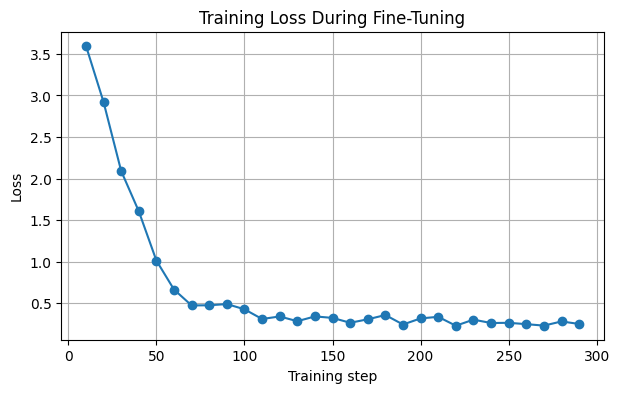

In [11]:
logged = [
    (entry["step"], entry["loss"])
    for entry in trainer.state.log_history
    if "loss" in entry
]

steps = [item[0] for item in logged]
losses = [item[1] for item in logged]

print("Loss values recorded:", len(losses))

if losses:
    print("First recorded loss:", round(losses[0], 3))
    print("Last recorded loss:", round(losses[-1], 3))

    plt.figure(figsize=(7, 4))
    plt.plot(steps, losses, marker="o")
    plt.title("Training Loss During Fine-Tuning")
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()


In [12]:
import os

trainer.save_model("gpt2-custom-dialogue")
tokenizer.save_pretrained("gpt2-custom-dialogue")

print("Saved files:", os.listdir("gpt2-custom-dialogue"))

base_wte = base_model.transformer.wte.weight
tuned_wte = finetuned_model.transformer.wte.weight

print()
print(
    "Base and fine-tuned models have the same weights:",
    torch.equal(base_wte, tuned_wte)
)
print(
    "Average weight change:",
    (base_wte - tuned_wte).abs().mean().item()
)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved files: ['tokenizer.json', 'training_args.bin', 'config.json', 'generation_config.json', 'model.safetensors', 'tokenizer_config.json']

Base and fine-tuned models have the same weights: False
Average weight change: 0.0007524641696363688


## Step 9: Generating Text with the Fine-Tuned Model

The fine-tuned GPT-2 receives exactly the same prompts, generation settings and seeds used in Step 3. This makes the before-and-after comparison more meaningful because the only intended change is the model's learned weights.


In [13]:
finetuned_model.eval()
finetuned_outputs = {}

for prompt_name, prompt in prompts.items():
    print("=====", prompt_name, "=====")
    print("Prompt:", prompt)

    for seed in seeds:
        text = generate_text(finetuned_model, prompt, seed)
        finetuned_outputs[(prompt_name, seed)] = text

        print()
        print("Seed", seed, ":")
        print(text)

    print()


===== Investigation prompt =====
Prompt: The detective placed the photograph on the table and said,

Seed 1 :
The detective placed the photograph on the table and said, "Look here."
That was wrong. The key had not yet been returned to its owner's home address. I should have left it at that location; fingerprints may tell us more than one story about who opened them . But they didn't give me enough detail before answering my question. Was this

Seed 2 :
The detective placed the photograph on the table and said, "That should tell us more than one story."
. .

Seed 3 :
The detective placed the photograph on the table and said, "Look here."
We thought it was going to be wrong. But we forgot what happened before that picture appeared beside another one: A map at a corner street had two corners marked by different words; they should have been identical but for some difference in order of appearance. We looked toward each other

===== Story prompt =====
Prompt: At midnight, the train stopped 

## Step 10: Before and After Comparison

The base-model and fine-tuned outputs are printed for the same prompts and seeds. The comparison focuses on whether the fine-tuned model has adopted the custom investigation-dialogue style.

A few simple measurements are also calculated to support the visual reading of the samples. These measurements are descriptive rather than a formal language-quality evaluation.


In [14]:
for prompt_name, prompt in prompts.items():
    print("=" * 80)
    print("PROMPT:", prompt)

    for seed in seeds:
        print("\n--- Seed", seed, "---")
        print("\nBASE MODEL:")
        print(base_outputs[(prompt_name, seed)])

        print("\nFINE-TUNED MODEL:")
        print(finetuned_outputs[(prompt_name, seed)])

    print()


PROMPT: The detective placed the photograph on the table and said,

--- Seed 1 ---

BASE MODEL:
The detective placed the photograph on the table and said, "We have to take it."
 [A police officer with a copy of his arrest file was shown in this photo.] The video shows two officers holding up handcuffs. One grabs one foot from another as he says that you can't walk down stairs without being arrested; then pulls out an automatic weapon

FINE-TUNED MODEL:
The detective placed the photograph on the table and said, "Look here."
That was wrong. The key had not yet been returned to its owner's home address. I should have left it at that location; fingerprints may tell us more than one story about who opened them . But they didn't give me enough detail before answering my question. Was this

--- Seed 2 ---

BASE MODEL:
The detective placed the photograph on the table and said, "Well you know that's a pretty good picture."
"But I think there was nothing to it. The other day we went out with an 

In [15]:
import re

def get_words(text):
    return re.findall(r"[a-z']+", text.lower())

training_vocab = set()

for line in clean_lines:
    training_vocab.update(get_words(line))

investigation_words = [
    "clue", "clues", "detective", "witness", "case",
    "evidence", "photograph", "key", "door", "question",
    "answer", "truth", "suspect", "station", "night",
    "secret", "letter", "voice", "shadow", "clock"
]

def count_style(outputs):
    total_words = 0
    in_vocab = 0
    questions = 0
    exclaims = 0
    investigation = 0

    for (prompt_name, seed), text in outputs.items():

        continuation = text[len(prompts[prompt_name]):]
        words = get_words(continuation)

        total_words += len(words)
        in_vocab += sum(word in training_vocab for word in words)
        investigation += sum(word in investigation_words for word in words)
        questions += continuation.count("?")
        exclaims += continuation.count("!")

    return {
        "Words generated": total_words,
        "Words found in training vocabulary (%)":
            round(100 * in_vocab / total_words, 1) if total_words else 0,
        "Question marks": questions,
        "Exclamation marks": exclaims,
        "Investigation-related words": investigation
    }

base_stats = count_style(base_outputs)
tuned_stats = count_style(finetuned_outputs)

print(f"{'Measure':<45}{'Base':>10}{'Fine-tuned':>14}")
print("-" * 70)

for measure in base_stats:
    print(
        f"{measure:<45}"
        f"{base_stats[measure]:>10}"
        f"{tuned_stats[measure]:>14}"
    )


Measure                                            Base    Fine-tuned
----------------------------------------------------------------------
Words generated                                     304           268
Words found in training vocabulary (%)             34.5          73.1
Question marks                                        0             0
Exclamation marks                                     0             0
Investigation-related words                           0             6


## Style Differences Between the Base and Fine-Tuned Model

The final observations should be based on the actual outputs produced above.

**1. Vocabulary and topic**

The base GPT-2 is a general-purpose pretrained model, so its continuation may move toward broad everyday, news-like or narrative vocabulary. The fine-tuned model is expected to use more investigation-related words because the training lines repeatedly contain clues, witnesses, evidence, questions and suspicious events.

**2. Tone and sentence style**

The custom dataset consists mainly of short, tense dialogue-like statements. After fine-tuning, the model should show more questioning, direct statements and suspense-oriented phrasing. The base model is less constrained by this style and may produce more general-purpose prose.

**Important:** The exact examples and counts should be taken from the generated outputs above rather than assumed in advance.


## Conclusion

Fine-tuning GPT-2 on a small original dialogue dataset is expected to shift the model toward the language patterns present in that dataset. In this experiment, the target style is a fictional detective/investigation conversation style.

The strongest evidence comes from the before-and-after outputs using the same prompts and generation settings. If the fine-tuned model produces more investigation vocabulary, direct questioning and suspenseful dialogue, those changes support the conclusion that the model learned characteristics of the custom style.

There are also limitations. The dataset is intentionally small, so the model may repeat phrases or lose some general coherence after fine-tuning. The experiment measures style adaptation rather than factual accuracy or general language quality. A larger dataset and a separate evaluation set would provide stronger evidence.

